Here, we use an even simpler approach to test the utility of learned weights in addition to network topology. We compare test prediction loss to that of a baseline model with binarized weights (essentially, if they're there or not). Weight values are set to 0 if the edge isn't present, and to the median of the absolute values of the learned parameters by scLEMBAS otherwise. To make the comparison even more stringent we:

- conserve the sign of known activating/inhibiting interactions
- if the sign is unknown, we set it to that of the learned scLEMBAS model

In [1]:
import os
import sys
import itertools
from collections import defaultdict
from contextlib import contextmanager, redirect_stdout, redirect_stderr

from tqdm import trange, tqdm

import numpy as np
import pandas as pd
import torch

from scipy import stats

import matplotlib
%matplotlib inline
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import mannwhitneyu

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import utilities as utils
from scLEMBAS.predict import get_prediction
from scLEMBAS.metrics import distances 

sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
from contextlib import contextmanager, redirect_stdout, redirect_stderr

@contextmanager
def suppress_output():
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            yield


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [5]:
from typing import Literal, Optional

n_ensembles = 10
seed_multiplier = 21234
def load_model(fold, ensemble_idx, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
    if from_trainer:
        if ensemble_idx < n_ensembles - 1:
            fn_trainer =  os.path.join(fn_base + 'trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        else:
            fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')


        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold, 
            adversarial_penalty = True, 
            randomize = False, 
            seed = seed_
        )
        
        if ensemble_idx < n_ensembles - 1: # +1 of the originally trained model
            fn_mod = os.path.join(fn_base + 'model_actual_ensemble{}.pt'.format(ensemble_idx))
        else:
            fn_mod = os.path.join(fn_base + 'model_actual.pt')
            
        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer


def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


# Actual Comparison

In [6]:
use_ensembles = True # will use the different seed initialized ensembles (generated for subnetwork analysis)
ensemble_iterables = range(5) if use_ensembles else [n_ensembles - 1]

In [8]:
if not os.path.isfile(os.path.join(data_path, 'processed', '{}_binarized_weight_baseline_loss.csv'.format(author))):

    loss_res = defaultdict(list)
    for fold, ensemble_idx in tqdm(itertools.product(range(5), ensemble_iterables)):
        split = get_split(fold = fold, author = author)

        test_conds = split['test_conds']
        train_barcodes = split['train_barcodes']
        test_barcodes = split['test_barcodes']

        ctrl_conds = sorted(set([tc.split('^')[0] + '^' + ctrl_pert for tc in test_conds]))
        ctrl_mask = tf_adata.obs.loc[train_barcodes, 'condition'].isin(ctrl_conds).values
        ctrl_cells = list(np.array(train_barcodes)[ctrl_mask])        

        mod, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, from_trainer = False)


        ################ ACTUAL MODEL LOSS ################ 
        with suppress_output():
            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes, 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
            )
        emd_loss = distances.get_EMD_loss(tf_adata, tf_adata_predicted)['Mean EMD Loss']

        loss_res['fold'].append(fold)
        loss_res['ensemble_idx'].append(ensemble_idx)
        loss_res['loss'].append(emd_loss)
        loss_res['model_type'].append('actual')



        ################ GENERATE BASELINE MODEL (median weight, binarization) ################ 

        learned_weights = mod.signaling_network.weights.data.clone()
        learned_weight_values = learned_weights[mod.signaling_network.edge_list]
        mean_weight = learned_weight_values.abs().mean()

        # initialize with mean learned weight
        weight_values = torch.full((len(mod.signaling_network.edge_list[0]),), mean_weight, 
                                  device = mod.signaling_network.weights.device, 
                                  dtype = mod.signaling_network.weights.dtype)

        # correct known MOAs
        weight_values[mod.signaling_network.edge_MOA[1,:]] = -weight_values[mod.signaling_network.edge_MOA[1,:]]
        # NOTE: this now has correct signs for known MOAs and positive signs for unknown MOAs create adj matrix

        # match unkown MOAs to learned signs
        signed_MOA = mod.signaling_network.edge_MOA[0, :].type(torch.long) - mod.signaling_network.edge_MOA[1, :].type(torch.long)
        unknown_mask = (signed_MOA == 0)
        unknown_learned_sign = torch.sign(learned_weight_values[unknown_mask])
        weight_values[unknown_mask] = weight_values[unknown_mask] * unknown_learned_sign

        # make it into the adjaceny matrix
        weights = torch.zeros(mod.signaling_network.n_network_nodes, mod.signaling_network.n_network_nodes, 
                              dtype=mod.signaling_network.weights.dtype, device = mod.signaling_network.weights.device)
        weights[mod.signaling_network.edge_list] = weight_values


        assert torch.equal(learned_weights == 0, weights == 0), 'There is an unexpected interaction in new adj. matrix'
        if mod.signaling_network.count_sign_mismatch() == 0:
            assert torch.equal(torch.sign(learned_weights), torch.sign(weights)), 'There is a sign mismatch in new adj matrix'

        mod.signaling_network.weights.data = weights

        ################ BASELINE MODEL LOSS ################ 

        with suppress_output():
            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes, 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
            )
        emd_loss_baseline = distances.get_EMD_loss(tf_adata, tf_adata_predicted)['Mean EMD Loss']

        loss_res['fold'].append(fold)
        loss_res['ensemble_idx'].append(ensemble_idx)
        loss_res['loss'].append(emd_loss_baseline)
        loss_res['model_type'].append('baseline')

    loss_res = pd.DataFrame(loss_res)
    loss_res.to_csv(os.path.join(data_path, 'processed', '{}_binarized_weight_baseline_loss.csv'.format(author)))
else:
    loss_res = pd.read_csv(os.path.join(data_path, 'processed', '{}_binarized_weight_baseline_loss.csv'.format(author)), 
                          index_col = 0)
    loss_res.model_type = pd.Categorical(loss_res.model_type, 
                                        categories = ['actual', 'baseline'], ordered = True)                


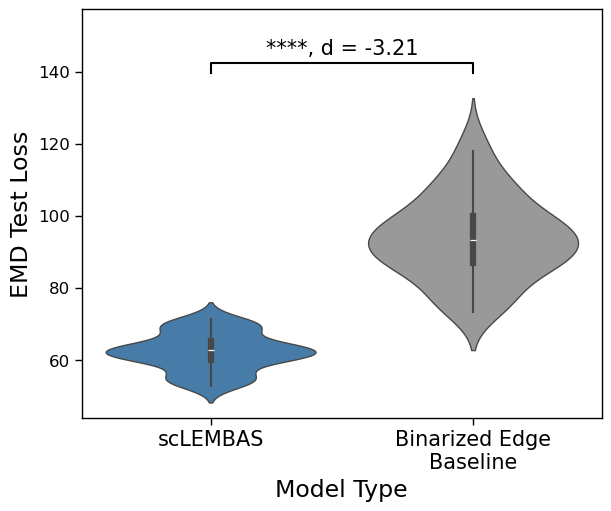

In [16]:
# helper used by the significance bracket
def _sig_stars(p):
    if p < 1e-4:  return "****"
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 5e-2:  return "*"
    return "ns"

%matplotlib inline

# --- stats ---
actual_mask = (loss_res.model_type == 'actual')
a = loss_res[actual_mask]['loss'].values
b = loss_res[~actual_mask]['loss'].values

cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b, alternative='less').pvalue

# non-actual model_type label -> Set1 gray (instead of purple)
other_type = loss_res.loc[~actual_mask, 'model_type'].iloc[0]
palette = {'actual': "#377eb8", other_type: '#999999'} #sns.color_palette('Set1')[2] }

with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 17,
        "axes.titlesize": 16,
        "legend.fontsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 12,
    }
):

    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

    sns.violinplot(data=loss_res, x='model_type', y='loss', ax=ax,
                   hue='model_type', palette=palette, legend=False)

    ax.set_ylabel('EMD Test Loss')
    ax.set_xlabel('Model Type')

    ticks = ax.get_xticks()
    ax.set_xticks(ticks)
    ax.set_xticklabels(['scLEMBAS', 'Binarized Edge\nBaseline'])

    # --- significance bracket: stars + Cohen's d on the same line ---
    y_lo, y_hi = ax.get_ylim()
    span = y_hi - y_lo
    bar_y = y_hi + span * 0.06        # bracket sits above the violins
    tick = span * 0.03                # end-cap drop
    vx1, vx2 = 0, 1                   # violin x-positions

    ax.plot(
        [vx1, vx1, vx2, vx2],
        [bar_y - tick, bar_y, bar_y, bar_y - tick],
        lw=1.5, c="black", clip_on=False,
    )
    ax.text(
        (vx1 + vx2) / 2.0, bar_y + span * 0.015,
        "{}, d = {:.2f}".format(_sig_stars(pval), cd),
        ha="center", va="bottom", fontsize=15,
    )
    ax.set_ylim(y_lo, bar_y + span * 0.16)

    fn_base = os.path.join(data_path, 'figures', '{}_binarized_baseline'.format(author))
    fig.savefig("{}.png".format(fn_base), dpi=600, bbox_inches='tight', transparent=True)
#     fig.savefig("{}.svg".format(fn_base), bbox_inches='tight', transparent=True)

    plt.show()